# Tutorial 12: Single-Cell Foundation Model Embeddings

This notebook demonstrates how to extract **cell embeddings** from
state-of-the-art single-cell RNA-seq foundation models using `embpy`.

All models are accessed through the
[Helical](https://github.com/helicalAI/helical) package, providing
a unified interface over:

| Family | Models available | Reference |
|---|---|---|
| **scGPT** | 33M-cell transformer | [Cui et al. 2024](https://doi.org/10.1038/s41592-024-02201-0) |
| **Geneformer** | v1 (6L/12L), v2 (12L/18L/20L), cancer-tuned | [Theodoris et al. 2023](https://doi.org/10.1038/s41586-023-06139-9) |
| **UCE** | Cross-species (36M cells) | [Rosen et al. 2023](https://doi.org/10.1101/2023.11.28.568918) |
| **TranscriptFormer** | Metazoa / Exemplar / Sapiens (CZI) | [Fang et al. 2025](https://doi.org/10.1101/2025.04.25.650731) |
| **Tahoe-x1** | 70M / 1B / 3B | — |
| **Cell2Sentence-Scale** | 2B (Pythia) / 27B (Gemma-2) | — |

### What you'll learn

1. List and inspect available single-cell foundation models
2. Load a model and extract cell embeddings from an AnnData object
3. Compare embeddings across different models
4. Visualise cell embedding spaces with PCA and UMAP
5. Store embeddings in AnnData for downstream analysis

### Requirements

```bash
pip install embpy[helical]
```

In [ ]:
import logging
import os
import tempfile

logging.basicConfig(level=logging.INFO)

tmpdir = "/lustre/groups/ml01/workspace/goncalo.pinto/tmp"
os.makedirs(tmpdir, exist_ok=True)
os.environ["TMPDIR"] = tmpdir
tempfile.tempdir = tmpdir

## 1. Discover available models

`embpy` provides a registry of all supported single-cell foundation models.

In [2]:
from embpy.models.singlecell_models import (
    list_singlecell_models,
    singlecell_info,
    get_singlecell_wrapper,
)

models = list_singlecell_models()
print(f"Available single-cell models ({len(models)}):")
for m in models:
    card = singlecell_info(m)
    print(f"  {m:35s} — {card.description}")

INFO:rdkit:Enabling RDKit 2025.09.5 jupyter extensions


Available single-cell models (25):
  scgpt                               — Transformer pre-trained on 33M+ human cells (Bo Wang Lab).
  geneformer_v1_6L                    — Geneformer v1 (6-layer, 10M params, 2048 input).
  geneformer_v1_12L                   — Geneformer v1 (12-layer, 40M params, 2048 input).
  geneformer_v1_12L_czi               — Geneformer v1 (12-layer) fine-tuned by CZI CELLxGENE.
  geneformer_v2_12L                   — Geneformer v2 (12-layer, 38M params, 4096 input, 95M cells).
  geneformer_v2_20L                   — Geneformer v2 (20-layer, 151M params, 4096 input).
  geneformer_v2_12L_cancer            — Geneformer v2 (12-layer) cancer-tuned variant.
  geneformer_v2_12L_104M              — Geneformer v2 (12-layer, 104M cells).
  geneformer_v2_12L_104M_cancer       — Geneformer v2 (12-layer, 104M cells) cancer-tuned.
  geneformer_v2_18L                   — Geneformer v2 (18-layer, 316M params, largest).
  uce                                 — Universal Cell Em

## 2. Load real data from sci-Plex

We load a random sample of **5,000 control cells** from the
sci-Plex 3 dataset (799K cells, 111K genes, 188 compounds across
A549/K562/MCF7 cell lines). This gives the models real gene
expression to work with.

In [3]:
import anndata as ad
import numpy as np
import pandas as pd

SCIPLEX_PATH = "/lustre/groups/ml01/workspace/goncalo.pinto/embpy/data/datasets/sciplex/srivatsan_2020_sciplex3.h5ad"
N_CELLS = 5_000

adata_full = ad.read_h5ad(SCIPLEX_PATH)
ctrl = adata_full[adata_full.obs["perturbation"] == "control"]

rng = np.random.default_rng(42)
idx = rng.choice(ctrl.n_obs, size=N_CELLS, replace=False)
adata = ctrl[idx].copy()

print(f"Loaded {adata.shape[0]:,} sci-Plex control cells x {adata.shape[1]:,} genes")
adata

Loaded 5,000 sci-Plex control cells x 110,983 genes


AnnData object with n_obs × n_vars = 5000 × 110983
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type'
    var: 'ensembl_id'

In [4]:
print(adata.X)

  (np.int32(0), np.int32(8))	1
  (np.int32(0), np.int32(28))	1
  (np.int32(0), np.int32(92))	1
  (np.int32(0), np.int32(135))	1
  (np.int32(0), np.int32(161))	2
  (np.int32(0), np.int32(211))	1
  (np.int32(0), np.int32(229))	2
  (np.int32(0), np.int32(231))	1
  (np.int32(0), np.int32(244))	1
  (np.int32(0), np.int32(250))	1
  (np.int32(0), np.int32(268))	2
  (np.int32(0), np.int32(288))	1
  (np.int32(0), np.int32(292))	1
  (np.int32(0), np.int32(295))	1
  (np.int32(0), np.int32(300))	1
  (np.int32(0), np.int32(304))	1
  (np.int32(0), np.int32(324))	1
  (np.int32(0), np.int32(336))	1
  (np.int32(0), np.int32(378))	3
  (np.int32(0), np.int32(381))	1
  (np.int32(0), np.int32(390))	3
  (np.int32(0), np.int32(396))	1
  (np.int32(0), np.int32(401))	1
  (np.int32(0), np.int32(412))	1
  (np.int32(0), np.int32(425))	1
  :	:
  (np.int32(4999), np.int32(29539))	1
  (np.int32(4999), np.int32(30222))	1
  (np.int32(4999), np.int32(30355))	1
  (np.int32(4999), np.int32(30429))	1
  (np.int32(4999), np

## 3. Load a model and extract embeddings

The workflow is always three steps:

1. **Instantiate** a wrapper (via the factory or directly)
2. **Load** the model weights onto a device
3. **Embed** cells from an AnnData

### 3a. scGPT

In [5]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [6]:
scgpt = get_singlecell_wrapper("scgpt", batch_size=10)
scgpt.load(device)

embs_scgpt = scgpt.embed_cells(adata)
print(f"scGPT embeddings: {embs_scgpt.shape}")
print(f"First cell (first 10 dims): {embs_scgpt[0, :10]}")

INFO:datasets:PyTorch version 2.7.0 available.
2026-05-03 20:26:26,020 - INFO:datasets:PyTorch version 2.7.0 available.
INFO:datasets:Polars version 1.40.0 available.
2026-05-03 20:26:26,150 - INFO:datasets:Polars version 1.40.0 available.
  warnings.warn(

2026-05-03 20:26:40,248 - WARNING:py.warnings:/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.pixi/envs/helical-gpu/lib/python3.12/site-packages/helical/models/scgpt/model_dir/transformer.py:135: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(

INFO:helical.models.scgpt.model:Model finished initializing.
2026-05-03 20:26:43,917 - INFO:helical.models.scgpt.model:Model finished initializing.
INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-03 20:26:43,919 - INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cel

scGPT embeddings: (5000, 512)
First cell (first 10 dims): [ 0.03291327  0.01790258  0.00508716  0.01068181  0.00175396 -0.00519093
 -0.00340226  0.02735573 -0.02072335  0.0532641 ]


### 3b. Geneformer

In [7]:
gf = get_singlecell_wrapper("geneformer_v2_12L", batch_size=10)
gf.load(device)

embs_gf = gf.embed_cells(adata)
print(f"Geneformer embeddings: {embs_gf.shape}")

`torch_dtype` is deprecated! Use `dtype` instead!
INFO:helical.models.geneformer.model:Model finished initializing.
2026-05-03 20:27:24,764 - INFO:helical.models.geneformer.model:Model finished initializing.
INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-03 20:27:24,766 - INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
INFO:embpy.models.singlecell_models:Loaded Geneformer 'gf-12L-38M-i4096' on cuda
2026-05-03 20:27:24,770 - INFO:embpy.models.singlecell_models:Loaded Geneformer 'gf-12L-38M-i4096' on cuda
INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-05-03 20:27:24,771 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 35163 / 110983 genes to Ensembl IDs.
2026-05-03 20:27:25,319 - INFO:helical.utils.mapping:Mapped 35163 / 110983 genes to Ensembl

  0%|          | 0/500 [00:00<?, ?it/s]

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-05-03 20:29:03,895 - INFO:helical.models.geneformer.model:Finished getting embeddings.


Geneformer embeddings: (5000, 512)


### 3c. UCE

In [ ]:
uce = get_singlecell_wrapper("uce", batch_size=10)
uce.load(device)

embs_uce = uce.embed_cells(adata)
print(f"UCE embeddings: {embs_uce.shape}")

INFO:helical.models.uce.model:Model finished initializing.
2026-05-03 20:29:17,789 - INFO:helical.models.uce.model:Model finished initializing.
INFO:helical.models.uce.model:'4layer_model' model is in 'eval' mode, on device 'cuda'.
2026-05-03 20:29:17,790 - INFO:helical.models.uce.model:'4layer_model' model is in 'eval' mode, on device 'cuda'.
INFO:embpy.models.singlecell_models:Loaded UCE on cuda
2026-05-03 20:29:17,793 - INFO:embpy.models.singlecell_models:Loaded UCE on cuda
INFO:helical.models.uce.model:Processing data for UCE.
2026-05-03 20:29:17,794 - INFO:helical.models.uce.model:Processing data for UCE.
INFO:helical.models.uce.gene_embeddings:Finished loading gene embeddings for 'human' from /home/icb/goncalo.pinto/.cache/helical/models/uce/protein_embeddings for model 'ESM2'.
2026-05-03 20:29:23,602 - INFO:helical.models.uce.gene_embeddings:Finished loading gene embeddings for 'human' from /home/icb/goncalo.pinto/.cache/helical/models/uce/protein_embeddings for model 'ESM2'.
IN

UCE embeddings: (5000, 1280)


### 3d. TranscriptFormer (CZI)

In [ ]:
tf = get_singlecell_wrapper("transcriptformer_sapiens", batch_size=10)
tf.load(device)

embs_tf = tf.embed_cells(adata)
print(f"TranscriptFormer-Sapiens embeddings: {embs_tf.shape}")

INFO:helical.models.transcriptformer.model:Loading cache config for tf_sapiens
2026-05-03 20:33:39,591 - INFO:helical.models.transcriptformer.model:Loading cache config for tf_sapiens
INFO:helical.models.transcriptformer.model:Merged cache config with user config for tf_sapiens
2026-05-03 20:33:39,600 - INFO:helical.models.transcriptformer.model:Merged cache config with user config for tf_sapiens
INFO:root:Loading vocabulary file: /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs/assay
2026-05-03 20:33:39,605 - INFO:root:Loading vocabulary file: /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs/assay
INFO:root:Loading ESM2 mappings from /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs
2026-05-03 20:33:39,607 - INFO:root:Loading ESM2 mappings from /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs
INFO:root:Building gene vocabulary
2026-05-03 20:33:53,475 - INFO:ro

23830


INFO:root:Gene mapping: 18860 / 110983 in vocab | not in vocab: 92123 | in vocab but zero expression: 2908 | in vocab and expressed: 15952
2026-05-03 20:34:13,268 - INFO:root:Gene mapping: 18860 / 110983 in vocab | not in vocab: 92123 | in vocab but zero expression: 2908 | in vocab and expressed: 15952
Embedding Cells: 100%|██████████| 500/500 [06:02<00:00,  1.38batch/s]
INFO:helical.models.transcriptformer.model:Combining predictions
2026-05-03 20:40:19,982 - INFO:helical.models.transcriptformer.model:Combining predictions
INFO:helical.models.transcriptformer.model:Returning 'cell_embeddings' from output.
2026-05-03 20:40:20,199 - INFO:helical.models.transcriptformer.model:Returning 'cell_embeddings' from output.


TranscriptFormer-Sapiens embeddings: (5000, 2048)


## 4. Compare embedding spaces

We can compare how different models organise cells by computing
pairwise cosine similarities or reducing to 2D.

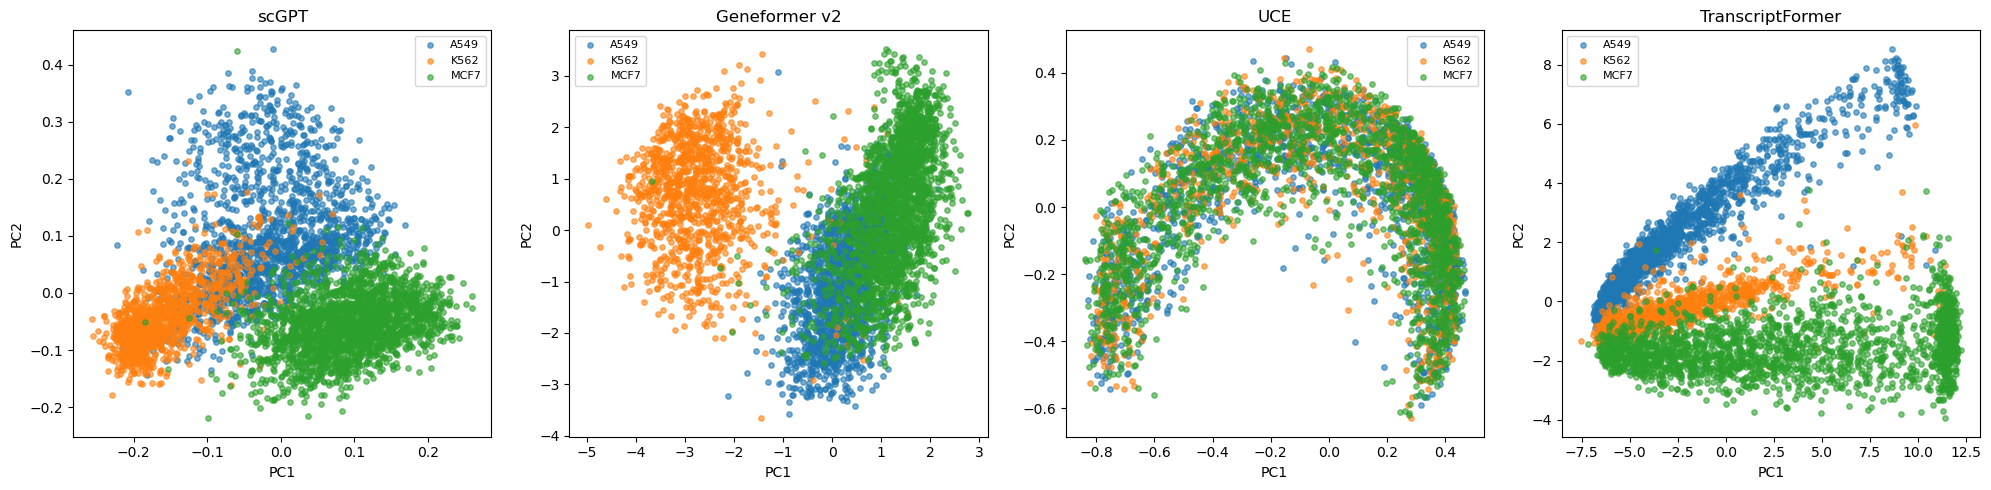

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cell_lines = np.asarray(adata.obs["cell_line"].values)

embedding_dict = {
    "scGPT": embs_scgpt,
    "Geneformer v2": embs_gf,
    "UCE": embs_uce,
    "TranscriptFormer": embs_tf,
}

fig, axes = plt.subplots(1, len(embedding_dict), figsize=(5 * len(embedding_dict), 5))

for ax, (name, embs) in zip(axes, embedding_dict.items()):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(embs)
    for cl in np.unique(cell_lines):
        mask = cell_lines == cl
        ax.scatter(coords[mask, 0], coords[mask, 1], label=str(cl), alpha=0.6, s=15)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Store embeddings in AnnData

It's convenient to store embeddings in `adata.obsm` for downstream analyses.

In [ ]:
adata.obsm["X_scgpt"] = embs_scgpt
adata.obsm["X_geneformer"] = embs_gf
adata.obsm["X_uce"] = embs_uce
adata.obsm["X_transcriptformer"] = embs_tf

print("Stored embedding keys:", list(adata.obsm.keys()))
adata

Stored embedding keys: ['X_scgpt', 'X_geneformer', 'X_uce', 'X_transcriptformer']


AnnData object with n_obs × n_vars = 5000 × 110983
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'total_counts', 'assay'
    var: 'ensembl_id', 'index', 'id_in_vocab', 'ensembl_id_collapsed'
    obsm: 'X_scgpt', 'X_geneformer', 'X_uce', 'X_transcriptformer'

## 6. Using the wrapper classes directly

Instead of the factory, you can instantiate wrappers directly for
more control over configuration.

In [ ]:
from embpy.models.singlecell_models import ScGPTWrapper, GeneformerWrapper

wrapper = ScGPTWrapper(batch_size=16)
wrapper.load(device)
print(f"Loaded: {wrapper}")
print(f"Embedding dim: {wrapper.embedding_dim}")

INFO:helical.models.scgpt.model:Model finished initializing.
2026-05-03 20:40:29,896 - INFO:helical.models.scgpt.model:Model finished initializing.
INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-03 20:40:29,897 - INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
INFO:embpy.models.singlecell_models:Loaded scGPT on cuda
2026-05-03 20:40:29,901 - INFO:embpy.models.singlecell_models:Loaded scGPT on cuda


Loaded: ScGPTWrapper(model_name='ScGPTWrapper', device='cuda')
Embedding dim: 512


## 7. Larger models: Tahoe-x1 and Cell2Sentence-Scale

These models are substantially larger than the transformer-era
foundation models above. In particular, **Cell2Sentence-Scale 2B**
is a full Gemma-2 LLM (~5 GB of weights in bf16, plus large
activation buffers) and the 27B variant needs multi-GPU.

If your notebook has already loaded several of the smaller models,
their weights are still resident on the GPU -- so before loading
Cell2Sentence we explicitly free them and subsample `adata` to a
size that comfortably fits on a single 20-40 GB GPU.


In [ ]:
# Tahoe-x1 (70M — smallest variant)
tahoe = get_singlecell_wrapper("tahoe_70m", batch_size=10)
tahoe.load(device)

embs_tahoe = tahoe.embed_cells(adata)
print(f"Tahoe-x1 70M embeddings: {embs_tahoe.shape}")

INFO:helical.models.tahoe.model:Loading Tahoe model (size: 70m) from Hugging Face...
2026-05-03 20:40:45,449 - INFO:helical.models.tahoe.model:Loading Tahoe model (size: 70m) from Hugging Face...
INFO:helical.models.tahoe.tahoe_x1.model.model:MosaicML recommends using config.init_device="meta" with Composer + FSDP for faster initialization.
2026-05-03 20:40:47,652 - INFO:helical.models.tahoe.tahoe_x1.model.model:MosaicML recommends using config.init_device="meta" with Composer + FSDP for faster initialization.
INFO:helical.models.tahoe.model:Model loaded with 12 transformer layers.
2026-05-03 20:40:53,966 - INFO:helical.models.tahoe.model:Model loaded with 12 transformer layers.
INFO:helical.models.tahoe.model:Tahoe model is in 'eval' mode, on device 'cuda' with embedding mode 'cell' and attention implementation 'torch'.
2026-05-03 20:40:53,969 - INFO:helical.models.tahoe.model:Tahoe model is in 'eval' mode, on device 'cuda' with embedding mode 'cell' and attention implementation 'torc

Embedding cells:   0%|          | 0/500 [00:00<?, ?it/s]

INFO:helical.models.tahoe.model:Finished extracting embeddings. Cell shape: (5000, 512)
2026-05-03 20:42:57,033 - INFO:helical.models.tahoe.model:Finished extracting embeddings. Cell shape: (5000, 512)


Tahoe-x1 70M embeddings: (5000, 512)


In [ ]:
import gc, os

# Reduce allocator fragmentation. For full effect this must be set
# BEFORE `import torch`; we set it here defensively so re-runs benefit.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Free every wrapper loaded earlier in this kernel. Each wrapper holds
# a `._model` reference to a large torch module whose parameters live
# on the GPU; dropping the wrapper is not enough -- we also clear the
# allocator's reserved blocks.
for _name in ("scgpt", "gf", "uce", "tf", "tahoe", "wrapper"):
    globals().pop(_name, None)
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
torch.cuda.synchronize()
free_gb, total_gb = (x / 1024**3 for x in torch.cuda.mem_get_info())
print(f"Free GPU memory before loading C2S: {free_gb:.2f} / {total_gb:.2f} GiB")

# Subsample to keep activations within a single 20-40 GB GPU. Cell2Sentence
# tokenizes cells into gene-rank sentences of up to ~9k tokens each,
# so even a batch size of 1 is memory-heavy.
N_C2S = 200
adata_small = adata[:N_C2S].copy()

c2s = get_singlecell_wrapper("cell2sentence_2b", batch_size=1)
c2s.load(device)

embs_c2s = c2s.embed_cells(adata_small)
print(f"Cell2Sentence-Scale 2B embeddings: {embs_c2s.shape}  (on {N_C2S} cells)")


INFO:helical.models.c2s.model:Using SDPA for attention implementation - default for CPU
2026-05-03 20:42:58,008 - INFO:helical.models.c2s.model:Using SDPA for attention implementation - default for CPU


Free GPU memory before loading C2S: 19.04 / 19.62 GiB


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:helical.models.c2s.model:Successfully loaded model
2026-05-03 20:43:13,000 - INFO:helical.models.c2s.model:Successfully loaded model
INFO:embpy.models.singlecell_models:Loaded Cell2Sentence-Scale '2B' on cuda
2026-05-03 20:43:13,002 - INFO:embpy.models.singlecell_models:Loaded Cell2Sentence-Scale '2B' on cuda
INFO:helical.models.c2s.model:Processing data
2026-05-03 20:43:13,003 - INFO:helical.models.c2s.model:Processing data
Processing cells: 100%|██████████| 200/200 [00:00<00:00, 3748.14it/s]
INFO:helical.models.c2s.model:Successfully processed data
2026-05-03 20:43:38,217 - INFO:helical.models.c2s.model:Successfully processed data
INFO:helical.models.c2s.model:Extracting embeddings from dataset
2026-05-03 20:43:38,220 - INFO:helical.models.c2s.model:Extracting embeddings from dataset
Processing embeddings:  12%|█▏        | 24/200 [00:13<01:24,  2.09it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 6.25 GiB. GPU 0 has a total capacity of 19.62 GiB of which 6.07 GiB is free. Process 2455455 has 1.31 GiB memory in use. Including non-PyTorch memory, this process has 13.44 GiB memory in use. Of the allocated memory 7.96 GiB is allocated by PyTorch, and 5.25 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 8. Cosine similarity between cell embeddings

Compute pairwise cosine similarity to check how well models
separate cell types.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim_scgpt = cosine_similarity(embs_scgpt)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim_scgpt, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("scGPT cell-cell cosine similarity")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Preprocessing Pipelines

`embpy` provides two preprocessing pipelines via `preprocess_counts()`:

- **`"standard"`** -- filter, normalize, log1p, HVG selection.
  Stores raw counts in `.layers["counts"]` and processed data in
  `.layers["log_normalized"]`, while `.X` is restored to raw.
- **`"raw"`** -- QC filtering only, raw counts in `.X`.

In [ ]:
from embpy.pp.singlecell import preprocess_counts

adata_processed = preprocess_counts(
    adata, pipeline="standard", n_top_genes=2000,
)

print("Layers:", list(adata_processed.layers.keys()))
print(f".X shape (raw counts): {adata_processed.X.shape}")
print(f".layers['counts'] shape: {adata_processed.layers['counts'].shape}")
print(f".layers['log_normalized'] shape: {adata_processed.layers['log_normalized'].shape}")
if "highly_variable" in adata_processed.var.columns:
    n_hvg = adata_processed.var["highly_variable"].sum()
    print(f"HVGs marked: {n_hvg}")

## 10. PCA and scVI Embeddings

Beyond foundation models, `embpy` supports classical PCA and scVI
(variational autoencoder) as cell embedding methods. These are available
through the same `embed_cells()` interface.

In [ ]:
from embpy.embedder import BioEmbedder

embedder = BioEmbedder(device="auto")

# PCA embedding (50 components on log-normalized HVGs)
result_pca = embedder.embed_cells(
    adata, models=["pca"],
    preprocessing="standard",
    n_pca_components=50,
    n_top_genes=2000,
)
print(f"PCA embedding: {result_pca.obsm['X_pca'].shape}")
print(f"Layers: {list(result_pca.layers.keys())}")

In [ ]:
# scVI latent space (requires: pip install scvi-tools)
try:
    result_scvi = embedder.embed_cells(
        adata, models=["scvi"],
        preprocessing="standard",
        n_latent=30,
        max_epochs=50,
        n_top_genes=2000,
    )
    print(f"scVI embedding: {result_scvi.obsm['X_scvi'].shape}")
except ImportError:
    print("scvi-tools not installed -- skipping scVI embedding")

## 11. Multi-Model Embedding in One Call

Pass multiple model keys to `embed_cells()` to compute all embeddings
at once. Each is stored under its own `.obsm` key.

In [ ]:
result = embedder.embed_cells(
    adata,
    models=["pca", "scgpt"],
    preprocessing="standard",
    n_pca_components=50,
    n_top_genes=2000,
    batch_size=10,
)

print("Embedding keys in .obsm:")
for key in sorted(result.obsm.keys()):
    print(f"  {key}: shape {result.obsm[key].shape}")

print(f"\n.X (raw counts): {result.X.shape}")
print(f"Layers: {list(result.layers.keys())}")
print(f"Metadata: {list(result.uns.get('embpy_cell_embeddings', {}).keys())}")

## Summary

This tutorial showed how to:

- **List** all 20+ single-cell foundation model variants via `list_singlecell_models()`
- **Load** any model with the 3-step pattern: instantiate → load → embed
- **Compare** embedding spaces across models using PCA visualisation
- **Store** embeddings in `adata.obsm` for seamless integration with scanpy/scvi

Key functions:

```python
from embpy.models.singlecell_models import (
    list_singlecell_models,   # discover available models
    singlecell_info,          # model metadata
    get_singlecell_wrapper,   # factory function
)
```

For the full list of models and variants, see the
[API reference](../api.md) or run `list_singlecell_models()`.